In [1]:
import json
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from common import *
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def save_per_layer_predictions(v_copy_arr, plot_name):
    # aggregate a scalar summary per layer for each sample in v_copy_arr
    per_layer_vals = {}
    for sample in v_copy_arr:
        if isinstance(sample, dict):
            items = sample.items()
        else:
            items = enumerate(sample)
        for k, v in items:
            # convert tensor/array to a single scalar (use mean absolute)
            if isinstance(v, torch.Tensor):
                val = v.detach().cpu().abs().mean().item()
            else:
                try:
                    arr = np.array(v)
                    val = float(np.abs(arr).mean())
                except Exception:
                    continue
            per_layer_vals.setdefault(str(k), []).append(val)

    if not per_layer_vals:
        print("No per-layer values to plot.")
        pass
    else:
        # ensure consistent ordering (try numeric if possible)
        names = list(per_layer_vals.keys())
        try:
            names = [n for n in sorted(names, key=lambda x: int(x))]
        except Exception:
            names = list(names)

        # compute mean per layer
        means = [np.mean(per_layer_vals[n]) for n in names]

        plt.figure(figsize=(8, 4))
        # plot each sample as a light line
        n_samples = len(next(iter(per_layer_vals.values())))
        for i in range(n_samples):
            ys = [per_layer_vals[n][i] for n in names]
            plt.plot(names, ys, color="gray", alpha=0.3, linewidth=0.8)
        # plot mean
        plt.plot(names, means, marker="o", color="red", linewidth=2, label="mean")
        plt.xlabel("Layer")
        plt.ylabel("Mean |prediction|")
        plt.title("Per-layer predictions across samples")
        plt.legend()
        plt.tight_layout()
        if DRAW_PLOT:
            plt.show()
        else:
            os.makedirs("./gpt", exist_ok=True)
            plt.savefig(f"./gpt/{plot_name}.png", dpi=150)
        plt.close()

In [3]:
model_name = "openai/gpt-oss-20b"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True, output_attentions=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

MXFP4 quantization requires Triton and kernels installed: CUDA requires Triton >= 3.4.0, XPU requires Triton >= 3.5.0, we will default to dequantizing the model to bf16


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/411 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

GptOssForCausalLM(
  (model): GptOssModel(
    (embed_tokens): Embedding(201088, 2880, padding_idx=199999)
    (layers): ModuleList(
      (0-23): 24 x GptOssDecoderLayer(
        (self_attn): GptOssAttention(
          (q_proj): Linear(in_features=2880, out_features=4096, bias=True)
          (k_proj): Linear(in_features=2880, out_features=512, bias=True)
          (v_proj): Linear(in_features=2880, out_features=512, bias=True)
          (o_proj): Linear(in_features=4096, out_features=2880, bias=True)
        )
        (mlp): GptOssMLP(
          (router): GptOssTopKRouter()
          (experts): GptOssExperts()
        )
        (input_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
        (post_attention_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
      )
    )
    (norm): GptOssRMSNorm((2880,), eps=1e-05)
    (rotary_emb): GptOssRotaryEmbedding()
  )
  (lm_head): Linear(in_features=2880, out_features=201088, bias=False)
)

In [4]:
text = "A sample text two"
inputs = tokenizer(text, return_tensors="pt").to(device)

outputs = model(**inputs)
logits = outputs.logits  # shape: [batch, seq_len, vocab_size]

print(outputs.hidden_states)

(tensor([[[ 0.1904,  0.4941,  0.6875,  ..., -0.0522,  0.0040,  0.0806],
         [ 0.0977,  0.8203,  1.2578,  ...,  0.0305, -0.0620,  0.4844],
         [-0.3086, -0.0160,  2.3906,  ...,  0.0518, -0.0645,  0.1562],
         [-0.2949,  0.8398,  0.5586,  ..., -0.1235, -0.0913, -0.1328]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<EmbeddingBackward0>), tensor([[[ 0.2471,  0.3242,  0.7539,  ..., -0.0581,  0.0046,  0.0400],
         [ 0.3750,  0.9375,  1.0625,  ..., -0.1348, -0.1855,  0.5742],
         [-0.5977,  0.3477,  2.6094,  ...,  0.0160, -0.1953, -0.0244],
         [-0.1406,  1.2969,  0.3125,  ..., -0.0635, -0.3066, -0.2383]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<AddBackward0>), tensor([[[ 0.3516,  0.4688,  0.5469,  ..., -0.1934,  0.0776, -0.1562],
         [ 0.2988,  1.0859,  1.2188,  ..., -0.1777, -0.0728,  0.4141],
         [ 0.0312,  0.2178,  3.0938,  ...,  0.9922, -0.5703,  0.2012],
         [-0.2500,  1.5000,  1.2344,  ...,  0.3965, -0.6094, -0.14

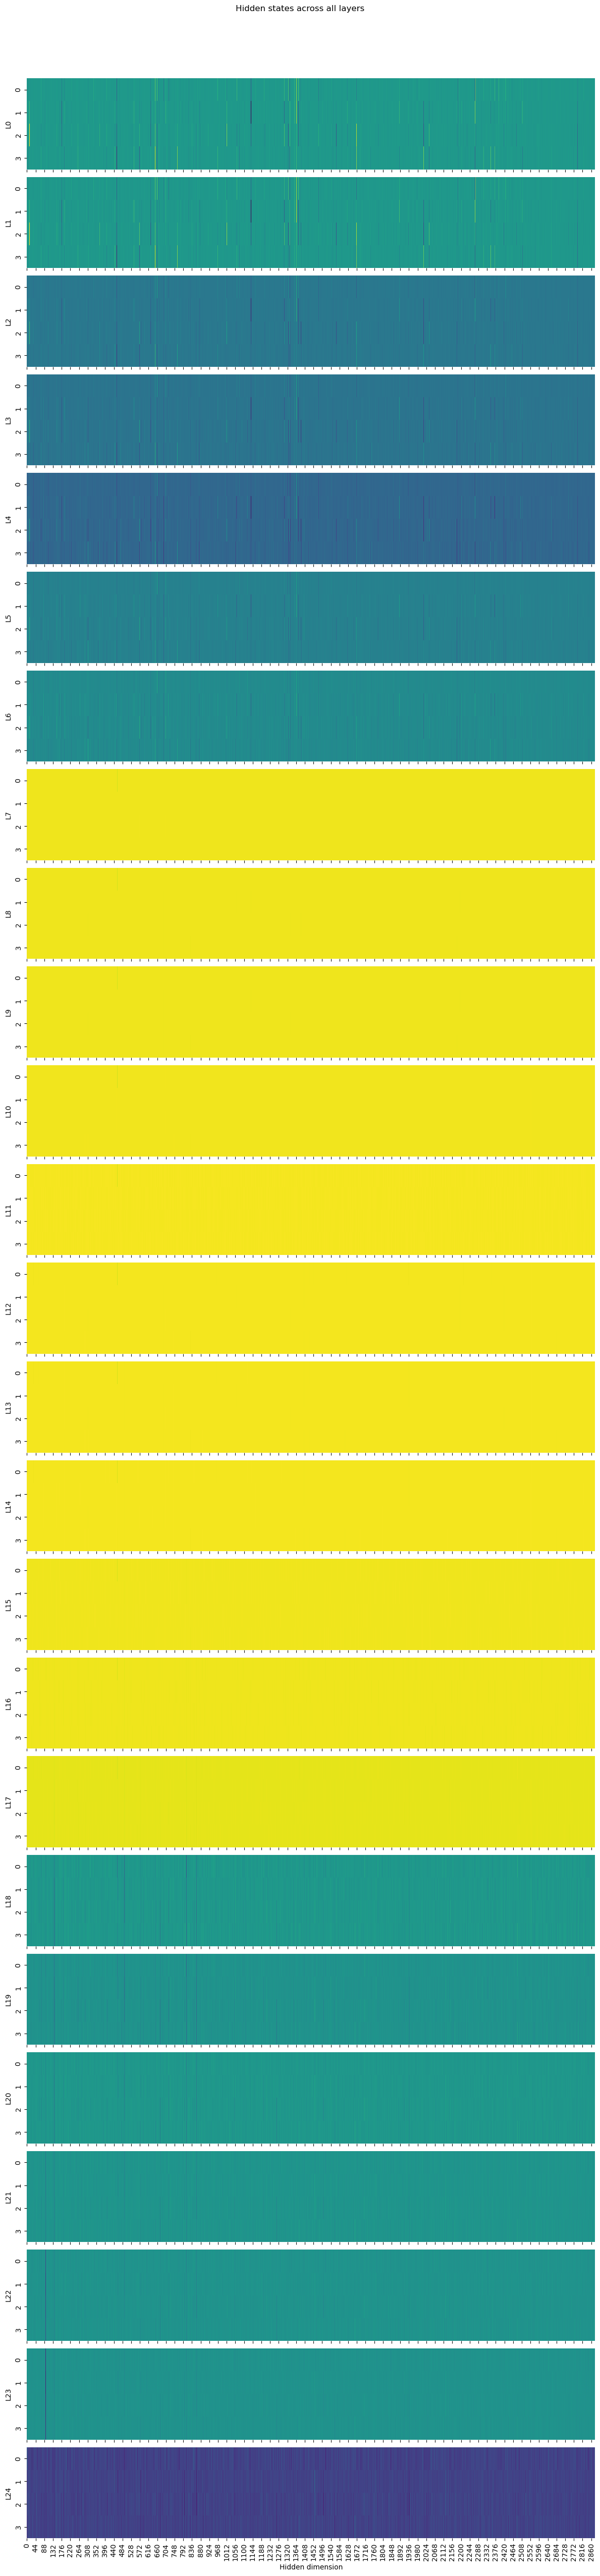

In [5]:
# un plot per layer
# per ogni subplot: x->dimensioni per ogni token, y=token in input(parola)

# Layer iniziali: token ancora legati a forma, vocabolario, sequenza
# Layer medi: pattern semantici, relazioni tra token
# Layer finali: rappresentazioni per la predizione del prossimo token 

hidden_states=outputs.hidden_states

num_layers = len(hidden_states)
seq_len = hidden_states[0].shape[1]

fig, axes = plt.subplots(
    nrows=num_layers,
    ncols=1,
    figsize=(12, 2 * num_layers),
    sharex=True
)

for i, ax in enumerate(axes):
    hs = hidden_states[i][0].detach().float().cpu().numpy()  # (seq_len, hidden_dim)
    sns.heatmap(
        hs,
        cmap="viridis",
        cbar=False,
        ax=ax
    )
    ax.set_ylabel(f"L{i}")

axes[-1].set_xlabel("Hidden dimension")
plt.suptitle("Hidden states across all layers", y=1.02)
plt.tight_layout()
plt.savefig("./gpt_test_plot.png")
plt.show()
